<a href="https://www.kaggle.com/code/misspriyagill/major-project?scriptVersionId=221240886" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [73]:
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
import warnings
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

warnings.filterwarnings("ignore", category=FutureWarning)

# Define dataset path
dataset_path = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset"

In [74]:
# Function to count the number of images in each folder
def count_images_in_folders(base_path, folder_list):
    counts = {}
    for folder in folder_list:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            counts[folder] = len(os.listdir(folder_path))  # Fixed file listing
        else:
            counts[folder] = 0
    return counts

folders = ["train/benign", "train/malignant", "test/benign", "test/malignant"]
image_counts = count_images_in_folders(dataset_path, folders)

# Print the count of images
for folder, count in image_counts.items():
    print(f"{folder}: {count} images")

train/benign: 5000 images
train/malignant: 4605 images
test/benign: 500 images
test/malignant: 500 images


In [75]:
# Define paths for train and test sets
train_benign_path = os.path.join(dataset_path, "train", "benign")
train_malignant_path = os.path.join(dataset_path, "train", "malignant")
test_benign_path = os.path.join(dataset_path, "test", "benign")
test_malignant_path = os.path.join(dataset_path, "test", "malignant")


In [76]:
# Function to check filename consistency
def check_filename_consistency(base_path, subfolders):
    for subfolder in subfolders:
        folder_path = os.path.join(base_path, subfolder)
        if os.path.exists(folder_path):
            for filename in os.listdir(folder_path):  # Fixed file listing
                if not re.match(r"melanoma_\d+\.jpg", filename):
                    print(f"Issue in {subfolder}: {filename}")

check_filename_consistency(dataset_path, folders)

In [77]:
# Creating a validation split
validation_base_path = "/kaggle/working/validation"
subfolders = ["train/benign", "train/malignant"]
os.makedirs(validation_base_path, exist_ok=True)

def create_validation_split(base_path, subfolders, validation_base_path, split_ratio=0.2):
    for subfolder in subfolders:
        source_folder = os.path.join(base_path, subfolder)
        if not os.path.exists(source_folder):
            print(f"Source folder {source_folder} does not exist. Skipping...")
            continue
        
        target_folder = os.path.join(validation_base_path, subfolder.split("/")[-1])
        os.makedirs(target_folder, exist_ok=True)

        images = os.listdir(source_folder)  # Fixed file listing
        labels = [subfolder] * len(images)
        _, val_images = train_test_split(images, test_size=split_ratio, random_state=42)  # Fixed train-test split
        
        for val_image in val_images:
            src = os.path.join(source_folder, val_image)
            dst = os.path.join(target_folder, val_image)
            if not os.path.exists(dst):
                os.symlink(src, dst)

create_validation_split(dataset_path, subfolders, validation_base_path)
print("Validation split created successfully!")

Validation split created successfully!


In [78]:
# Count images in train/test directories
train_benign = len(os.listdir(train_benign_path))
train_malignant = len(os.listdir(train_malignant_path))
test_benign = len(os.listdir(test_benign_path))
test_malignant = len(os.listdir(test_malignant_path))

# Print counts
print(f"train_benign: {train_benign} images")
print(f"train_malignant: {train_malignant} images")
print(f"test_benign: {test_benign} images")
print(f"test_malignant: {test_malignant} images")

train_benign: 5000 images
train_malignant: 4605 images
test_benign: 500 images
test_malignant: 500 images


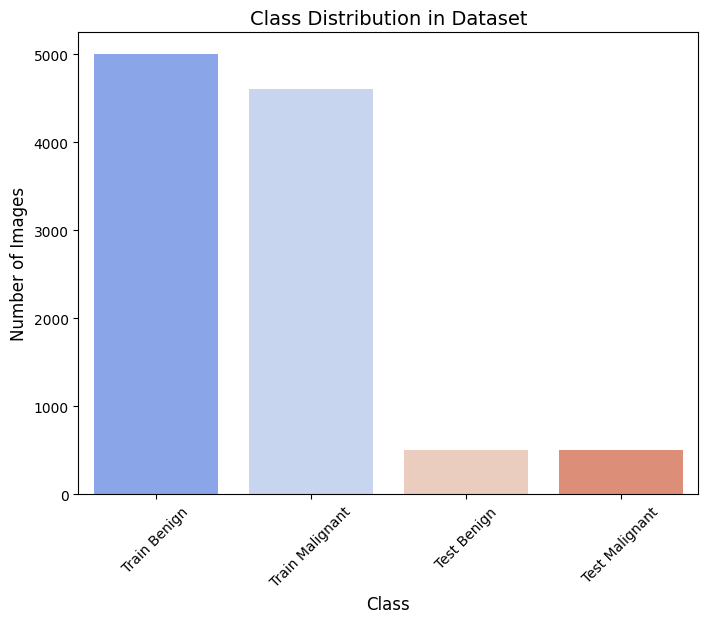

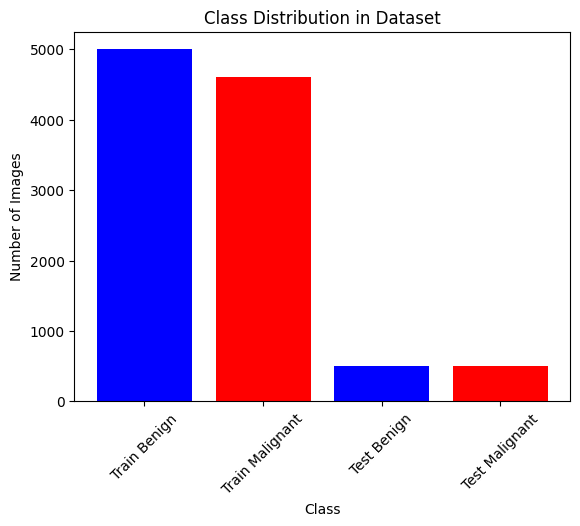

Train Benign to Malignant Ratio: 1.09
Test Benign to Malignant Ratio: 1.00


In [79]:
# Dictionary for visualization
class_counts = {
    "Train Benign": train_benign,
    "Train Malignant": train_malignant,
    "Test Benign": test_benign,
    "Test Malignant": test_malignant
}

# Bar Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='coolwarm')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Bar Plot using Matplotlib
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red', 'blue', 'red'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Dataset')
plt.xticks(rotation=45) 
plt.show()

# Train-test ratio
train_ratio = train_benign / train_malignant
test_ratio = test_benign / test_malignant

print(f"Train Benign to Malignant Ratio: {train_ratio:.2f}")
print(f"Test Benign to Malignant Ratio: {test_ratio:.2f}")

In [86]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  


In [87]:
# Defining train and validation generators 
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='training'  
)

val_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='validation'  
)


Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
